# DA6401 Assignment 1 — Weights & Biases Experiments

This notebook covers all W&B report sections:
- 2.1 Data Exploration
- 2.2 Hyperparameter Sweep
- 2.3 Optimizer Showdown
- 2.4 Vanishing Gradient Analysis
- 2.5 Dead Neuron Investigation
- 2.6 Loss Function Comparison
- 2.7 Global Performance Analysis
- 2.8 Error Analysis (Confusion Matrix)
- 2.9 Weight Initialization & Symmetry
- 2.10 Fashion-MNIST Transfer Challenge


In [2]:
import sys, os
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import wandb
from utils.data_loader import load_data, FASHION_CLASSES, MNIST_CLASSES
from ann.neural_network import NeuralNetwork
from ann.objective_functions import get_loss
from sklearn.metrics import confusion_matrix, f1_score
import seaborn as sns

WANDB_PROJECT = 'da6401_assignment_1'
WANDB_ENTITY  = 'agrawalritik2001-'

# Helper: build args namespace
def make_args(**kwargs):
    defaults = dict(
        dataset='mnist', num_layers=3, hidden_size=128,
        activation='relu', optimizer='rmsprop', learning_rate=0.001,
        weight_decay=0.0, batch_size=32, epochs=10,
        loss='cross_entropy', weight_init='xavier',
        input_size=784, output_size=10
    )
    defaults.update(kwargs)
    return type('Args', (), defaults)()

# Load Fashion-MNIST once
(X_train, y_train), (X_val, y_val), (X_test, y_test), class_names = load_data('mnist', val_split=0.1)
print('Data loaded.')

Dataset: mnist
  Train : 54000 samples
  Val   : 6000   samples
  Test  : 10000   samples
  Input : 784 features
Data loaded.


## 2.1 Data Exploration — Sample Images per Class

In [3]:
run = wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name='data_exploration', job_type='eda')

# Collect 5 images per class
columns = ['label'] + [f'img_{i}' for i in range(5)]
table   = wandb.Table(columns=columns)

# Combine train + val for sampling
X_all = np.vstack([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

for cls in range(10):
    idx    = np.where(y_all == cls)[0]
    sample = idx[:5]
    images = [wandb.Image(X_all[s].reshape(28,28), caption=class_names[cls]) for s in sample]
    table.add_data(class_names[cls], *images)

wandb.log({'sample_images': table})
run.finish()
print('Section 2.1 done.')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.
wandb: Currently logged in as: agrawalritik2001 (agrawalritik2001-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Section 2.1 done.


## 2.2 Hyperparameter Sweep (≥100 runs)

In [2]:
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_acc', 'goal': 'maximize'},
    'parameters': {
        'learning_rate': {'values': [0.01, 0.001, 0.0001]},
        'optimizer':     {'values': ['sgd', 'momentum', 'nag', 'rmsprop']},
        'num_layers':    {'values': [2, 3, 4]},
        'hidden_size':   {'values': [64, 128]},
        'activation':    {'values': ['relu', 'sigmoid', 'tanh']},
        'weight_init':   {'values': ['random', 'xavier']},
        'batch_size':    {'values': [32, 64]},
        'weight_decay':  {'values': [0.0, 0.0005, 0.001]},
    }
}

def sweep_train():
    run = wandb.init(settings=wandb.Settings(silent=True))
    cfg = wandb.config
    try:
        args = make_args(
            dataset       = 'mnist',
            learning_rate = cfg.learning_rate,
            optimizer     = cfg.optimizer,
            num_layers    = cfg.num_layers,
            hidden_size   = cfg.hidden_size,
            activation    = cfg.activation,
            weight_init   = cfg.weight_init,
            batch_size    = cfg.batch_size,
            weight_decay  = cfg.weight_decay,
            epochs        = 5,
        )
        model = NeuralNetwork(args)
        model.train(
            X_train, y_train,
            X_val=X_val, y_val=y_val,
            epochs=args.epochs,
            batch_size=args.batch_size,
            wandb_log=True,
        )
    except Exception as e:
        print(f"Run failed: {e}")
        wandb.log({'val_acc': 0.0})
    finally:
        run.finish()

sweep_id = wandb.sweep(sweep_config, project=WANDB_PROJECT, entity=WANDB_ENTITY)
print(f'Sweep ID: {sweep_id}')
wandb.agent(sweep_id, function=sweep_train, count=101)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.


Create sweep with ID: 1s1oilm3
Sweep URL: https://wandb.ai/agrawalritik2001-/da6401_assignment_1/sweeps/1s1oilm3
Sweep ID: 1s1oilm3


wandb: Agent Starting Run: ht3qor0d with config:
wandb: 	activation: relu
wandb: 	batch_size: 32
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.0001
wandb: 	num_layers: 3
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.


Epoch   1/5 | Train Loss: 1.3125 | Train Acc: 0.6438 | Val Loss: 0.9767 | Val Acc: 0.6467
Epoch   2/5 | Train Loss: 0.8943 | Train Acc: 0.7556 | Val Loss: 0.7959 | Val Acc: 0.7562
Epoch   3/5 | Train Loss: 0.6138 | Train Acc: 0.8457 | Val Loss: 0.5216 | Val Acc: 0.8452
Epoch   4/5 | Train Loss: 0.4756 | Train Acc: 0.8735 | Val Loss: 0.4656 | Val Acc: 0.8710
Epoch   5/5 | Train Loss: 0.4215 | Train Acc: 0.8841 | Val Loss: 0.4261 | Val Acc: 0.8823


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: x92lt1lt with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 3
wandb: 	optimizer: momentum
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.


...

Epoch   1/5 | Train Loss: 1.2549 | Train Acc: 0.8607 | Val Loss: 0.4883 | Val Acc: 0.8562
Epoch   2/5 | Train Loss: 0.3825 | Train Acc: 0.9066 | Val Loss: 0.3319 | Val Acc: 0.9067
Epoch   3/5 | Train Loss: 0.2949 | Train Acc: 0.9225 | Val Loss: 0.2838 | Val Acc: 0.9212
Epoch   4/5 | Train Loss: 0.2527 | Train Acc: 0.9358 | Val Loss: 0.2526 | Val Acc: 0.9302
Epoch   5/5 | Train Loss: 0.2235 | Train Acc: 0.9386 | Val Loss: 0.2389 | Val Acc: 0.9313


wandb: Agent Starting Run: 9rb8kqdt with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.01
wandb: 	num_layers: 4
wandb: 	optimizer: nag
wandb: 	weight_decay: 0.001
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.


Epoch   1/5 | Train Loss: 0.4530 | Train Acc: 0.9371 | Val Loss: 0.2285 | Val Acc: 0.9293
Epoch   2/5 | Train Loss: 0.1659 | Train Acc: 0.9598 | Val Loss: 0.1708 | Val Acc: 0.9535
Epoch   3/5 | Train Loss: 0.1293 | Train Acc: 0.9691 | Val Loss: 0.1390 | Val Acc: 0.9592
Epoch   4/5 | Train Loss: 0.1096 | Train Acc: 0.9740 | Val Loss: 0.1265 | Val Acc: 0.9617
Epoch   5/5 | Train Loss: 0.0980 | Train Acc: 0.9767 | Val Loss: 0.1279 | Val Acc: 0.9615


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: fxyfm5vp with config:
wandb: 	activation: relu
wandb: 	batch_size: 64
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.001
wandb: 	num_layers: 4
wandb: 	optimizer: nag
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.


Epoch   1/5 | Train Loss: 1.2357 | Train Acc: 0.8657 | Val Loss: 0.4797 | Val Acc: 0.8648
Epoch   2/5 | Train Loss: 0.3838 | Train Acc: 0.9056 | Val Loss: 0.3348 | Val Acc: 0.9045
Epoch   3/5 | Train Loss: 0.3048 | Train Acc: 0.9172 | Val Loss: 0.2957 | Val Acc: 0.9152
Epoch   4/5 | Train Loss: 0.2656 | Train Acc: 0.9298 | Val Loss: 0.2596 | Val Acc: 0.9247
Epoch   5/5 | Train Loss: 0.2377 | Train Acc: 0.9354 | Val Loss: 0.2392 | Val Acc: 0.9325


## 2.3 Optimizer Showdown

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.
wandb: Currently logged in as: agrawalritik2001 (agrawalritik2001-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/10 | Train Loss: 2.0331 | Train Acc: 0.6704 | Val Loss: 1.6224 | Val Acc: 0.6628
Epoch   2/10 | Train Loss: 1.1262 | Train Acc: 0.8128 | Val Loss: 0.7868 | Val Acc: 0.8070
Epoch   3/10 | Train Loss: 0.6413 | Train Acc: 0.8524 | Val Loss: 0.5531 | Val Acc: 0.8498
Epoch   4/10 | Train Loss: 0.4952 | Train Acc: 0.8759 | Val Loss: 0.4577 | Val Acc: 0.8712
Epoch   5/10 | Train Loss: 0.4258 | Train Acc: 0.8883 | Val Loss: 0.4080 | Val Acc: 0.8832
Epoch   6/10 | Train Loss: 0.3848 | Train Acc: 0.8964 | Val Loss: 0.3747 | Val Acc: 0.8928
Epoch   7/10 | Train Loss: 0.3576 | Train Acc: 0.9025 | Val Loss: 0.3523 | Val Acc: 0.9007
Epoch   8/10 | Train Loss: 0.3373 | Train Acc: 0.9068 | Val Loss: 0.3370 | Val Acc: 0.9042
Epoch   9/10 | Train Loss: 0.3216 | Train Acc: 0.9104 | Val Loss: 0.3241 | Val Acc: 0.9075
Epoch  10/10 | Train Loss: 0.3084 | Train Acc: 0.9137 | Val Loss: 0.3137 | Val Acc: 0.9115


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▅▆▇▇█████
train_loss,█▄▂▂▁▁▁▁▁▁
val_acc,▁▅▆▇▇▇████
val_loss,█▄▂▂▂▁▁▁▁▁
epoch,10
train_acc,0.9137
train_loss,0.30838
val_acc,0.9115
val_loss,0.31375


Epoch   1/10 | Train Loss: 0.6799 | Train Acc: 0.9086 | Val Loss: 0.3249 | Val Acc: 0.9077
Epoch   2/10 | Train Loss: 0.2769 | Train Acc: 0.9301 | Val Loss: 0.2581 | Val Acc: 0.9243
Epoch   3/10 | Train Loss: 0.2192 | Train Acc: 0.9423 | Val Loss: 0.2243 | Val Acc: 0.9358
Epoch   4/10 | Train Loss: 0.1820 | Train Acc: 0.9539 | Val Loss: 0.1876 | Val Acc: 0.9468
Epoch   5/10 | Train Loss: 0.1563 | Train Acc: 0.9589 | Val Loss: 0.1751 | Val Acc: 0.9493
Epoch   6/10 | Train Loss: 0.1368 | Train Acc: 0.9620 | Val Loss: 0.1651 | Val Acc: 0.9520
Epoch   7/10 | Train Loss: 0.1215 | Train Acc: 0.9689 | Val Loss: 0.1467 | Val Acc: 0.9587
Epoch   8/10 | Train Loss: 0.1085 | Train Acc: 0.9700 | Val Loss: 0.1431 | Val Acc: 0.9600
Epoch   9/10 | Train Loss: 0.0979 | Train Acc: 0.9735 | Val Loss: 0.1351 | Val Acc: 0.9615
Epoch  10/10 | Train Loss: 0.0888 | Train Acc: 0.9759 | Val Loss: 0.1310 | Val Acc: 0.9618


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▃▅▆▆▇▇▇██
train_loss,█▃▃▂▂▂▁▁▁▁
val_acc,▁▃▅▆▆▇████
val_loss,█▆▄▃▃▂▂▁▁▁
epoch,10
train_acc,0.97589
train_loss,0.08884
val_acc,0.96183
val_loss,0.13103


Epoch   1/10 | Train Loss: 0.7017 | Train Acc: 0.9073 | Val Loss: 0.3276 | Val Acc: 0.9062
Epoch   2/10 | Train Loss: 0.2848 | Train Acc: 0.9288 | Val Loss: 0.2595 | Val Acc: 0.9270
Epoch   3/10 | Train Loss: 0.2279 | Train Acc: 0.9414 | Val Loss: 0.2189 | Val Acc: 0.9358
Epoch   4/10 | Train Loss: 0.1920 | Train Acc: 0.9518 | Val Loss: 0.1907 | Val Acc: 0.9462
Epoch   5/10 | Train Loss: 0.1651 | Train Acc: 0.9548 | Val Loss: 0.1816 | Val Acc: 0.9485
Epoch   6/10 | Train Loss: 0.1454 | Train Acc: 0.9633 | Val Loss: 0.1575 | Val Acc: 0.9567
Epoch   7/10 | Train Loss: 0.1278 | Train Acc: 0.9664 | Val Loss: 0.1479 | Val Acc: 0.9585
Epoch   8/10 | Train Loss: 0.1144 | Train Acc: 0.9692 | Val Loss: 0.1383 | Val Acc: 0.9620
Epoch   9/10 | Train Loss: 0.1031 | Train Acc: 0.9744 | Val Loss: 0.1277 | Val Acc: 0.9640
Epoch  10/10 | Train Loss: 0.0940 | Train Acc: 0.9757 | Val Loss: 0.1208 | Val Acc: 0.9675


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▃▄▆▆▇▇▇██
train_loss,█▃▃▂▂▂▁▁▁▁
val_acc,▁▃▄▆▆▇▇▇██
val_loss,█▆▄▃▃▂▂▂▁▁
epoch,10
train_acc,0.97569
train_loss,0.09396
val_acc,0.9675
val_loss,0.12076


Epoch   1/10 | Train Loss: 0.2372 | Train Acc: 0.9631 | Val Loss: 0.1450 | Val Acc: 0.9568
Epoch   2/10 | Train Loss: 0.1098 | Train Acc: 0.9783 | Val Loss: 0.1168 | Val Acc: 0.9690
Epoch   3/10 | Train Loss: 0.0829 | Train Acc: 0.9762 | Val Loss: 0.1379 | Val Acc: 0.9662
Epoch   4/10 | Train Loss: 0.0703 | Train Acc: 0.9827 | Val Loss: 0.1285 | Val Acc: 0.9697
Epoch   5/10 | Train Loss: 0.0629 | Train Acc: 0.9897 | Val Loss: 0.1217 | Val Acc: 0.9727
Epoch   6/10 | Train Loss: 0.0556 | Train Acc: 0.9902 | Val Loss: 0.1173 | Val Acc: 0.9738
Epoch   7/10 | Train Loss: 0.0501 | Train Acc: 0.9913 | Val Loss: 0.1354 | Val Acc: 0.9747
Epoch   8/10 | Train Loss: 0.0460 | Train Acc: 0.9928 | Val Loss: 0.1701 | Val Acc: 0.9723
Epoch   9/10 | Train Loss: 0.0440 | Train Acc: 0.9906 | Val Loss: 0.1761 | Val Acc: 0.9750
Epoch  10/10 | Train Loss: 0.0451 | Train Acc: 0.9900 | Val Loss: 0.2151 | Val Acc: 0.9713


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▅▄▆▇▇███▇
train_loss,█▃▂▂▂▁▁▁▁▁
val_acc,▁▆▅▆▇██▇█▇
val_loss,▃▁▃▂▁▁▂▅▅█
epoch,10
train_acc,0.98998
train_loss,0.04507
val_acc,0.97133
val_loss,0.21513


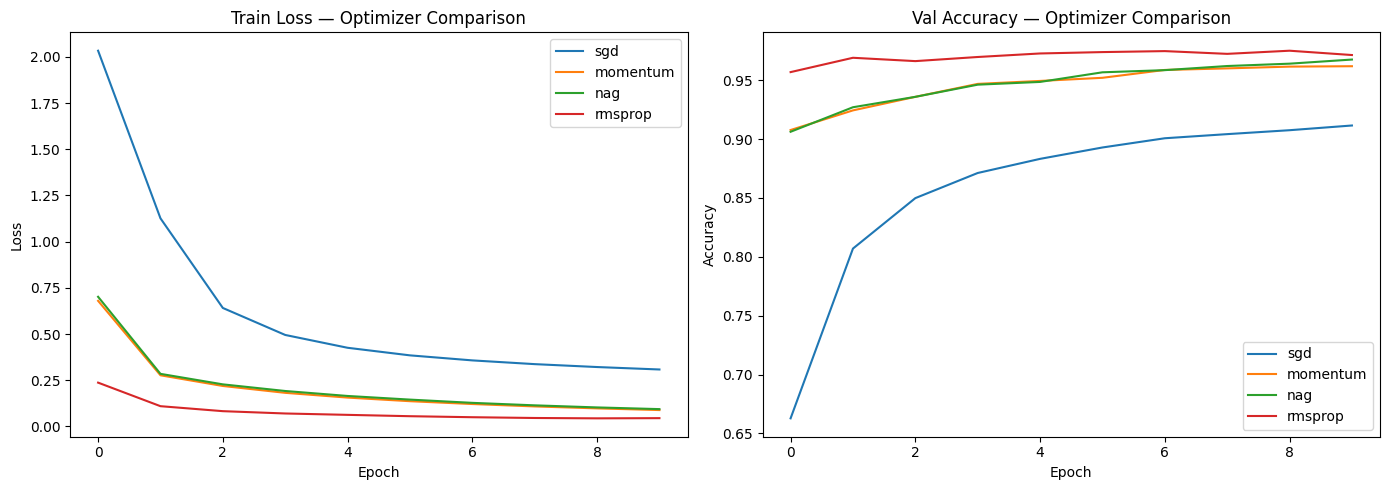

Section 2.3 done.


In [ ]:
optimizers_to_compare = ['sgd', 'momentum', 'nag', 'rmsprop']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Use higher lr for SGD, lower for adaptive optimizers
lr_map = {
    'sgd':      0.001,
    'momentum': 0.001,
    'nag':      0.001,
    'rmsprop':  0.001,
}

for opt_name in optimizers_to_compare:
    lr = lr_map[opt_name]
    run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY,
        name=f'optimizer_{opt_name}',
        reinit='finish_previous',
        config={'optimizer': opt_name, 'hidden_size': 128, 'num_layers': 3,
                'activation': 'relu', 'epochs': 10, 'lr': lr, 'dataset': 'mnist'}
    )
    args  = make_args(
        dataset    = 'mnist',
        optimizer  = opt_name,
        hidden_size= 128,
        num_layers = 3,
        activation = 'relu',
        epochs     = 10,
        learning_rate = lr,
    )
    model   = NeuralNetwork(args)
    history = model.train(
        X_train, y_train,
        X_val=X_val, y_val=y_val,
        epochs=10,
        batch_size=32,
        wandb_log=True,
    )

    axes[0].plot(history['train_loss'], label=opt_name)
    axes[1].plot(history['val_acc'],    label=opt_name)
    run.finish()

axes[0].set_title('Train Loss — Optimizer Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Val Accuracy — Optimizer Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()
print('Section 2.3 done.')

## 2.4 Vanishing Gradient Analysis

In [3]:
def train_with_grad_logging(activation, num_layers=4, epochs=15, run_name=None):
    """Train and log gradient norms for the first hidden layer."""
    run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY,
        name=run_name or f'grad_analysis_{activation}',
        reinit='finish_previous',
        config={'activation': activation, 'num_layers': num_layers,
                'dataset': 'mnist'}
    )
    args  = make_args(
        dataset    = 'mnist',   
        activation = activation,
        optimizer  = 'rmsprop',
        num_layers = num_layers,
        hidden_size= 128,
        learning_rate = 0.001,
        epochs     = epochs
    )
    model   = NeuralNetwork(args)
    history = model.train(
        X_train, y_train,
        X_val=X_val, y_val=y_val,
        epochs=epochs,
        batch_size=32,
        wandb_log=True,
        log_gradient_norms=True,
    )
    run.finish()
    return history

train_with_grad_logging('sigmoid', num_layers=6, epochs=15, run_name='grad_sigmoid_deep')
train_with_grad_logging('relu',    num_layers=6, epochs=15, run_name='grad_relu_deep')
print('Section 2.4 done.')

Epoch   1/15 | Train Loss: 0.8960 | Train Acc: 0.8813 | Val Loss: 0.4044 | Val Acc: 0.8817
Epoch   2/15 | Train Loss: 0.3258 | Train Acc: 0.9056 | Val Loss: 0.3418 | Val Acc: 0.9012
Epoch   3/15 | Train Loss: 0.2270 | Train Acc: 0.9544 | Val Loss: 0.1952 | Val Acc: 0.9432
Epoch   4/15 | Train Loss: 0.1837 | Train Acc: 0.9259 | Val Loss: 0.3035 | Val Acc: 0.9165
Epoch   5/15 | Train Loss: 0.1579 | Train Acc: 0.9674 | Val Loss: 0.1514 | Val Acc: 0.9572
Epoch   6/15 | Train Loss: 0.1376 | Train Acc: 0.9670 | Val Loss: 0.1635 | Val Acc: 0.9543
Epoch   7/15 | Train Loss: 0.1222 | Train Acc: 0.9725 | Val Loss: 0.1577 | Val Acc: 0.9567
Epoch   8/15 | Train Loss: 0.1108 | Train Acc: 0.9695 | Val Loss: 0.1558 | Val Acc: 0.9595
Epoch   9/15 | Train Loss: 0.1032 | Train Acc: 0.9760 | Val Loss: 0.1440 | Val Acc: 0.9627
Epoch  10/15 | Train Loss: 0.0947 | Train Acc: 0.9783 | Val Loss: 0.1553 | Val Acc: 0.9622
Epoch  11/15 | Train Loss: 0.0865 | Train Acc: 0.9827 | Val Loss: 0.1410 | Val Acc: 0.9655

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm_layer_0,▂▇▂▅▁▅▃▂▇▂██▅▁▁
grad_norm_layer_1,▂█▂▅▁▃▃▂▅▁▅█▅▁▁
grad_norm_layer_2,▂█▂▄▁▃▃▂▅▁▃▆▄▁▁
grad_norm_layer_3,▂█▂▅▁▃▄▂▇▂▃█▆▁▁
grad_norm_layer_4,▃▇▂▅▁▃▅▂█▂▅█▅▁▁
grad_norm_layer_5,▄▇▂▅▁▄▄▂█▂▆▇▆▁▁
grad_norm_layer_6,▇█▃▅▁▄▄▂▅▂▅▅▄▁▁
train_acc,▁▃▆▄▇▇▇▇▇▇█▇██▇
train_loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁
+2,...


Epoch   1/15 | Train Loss: 0.2779 | Train Acc: 0.9576 | Val Loss: 0.2191 | Val Acc: 0.9493
Epoch   2/15 | Train Loss: 0.1422 | Train Acc: 0.9742 | Val Loss: 0.1421 | Val Acc: 0.9655
Epoch   3/15 | Train Loss: 0.1255 | Train Acc: 0.9722 | Val Loss: 0.1562 | Val Acc: 0.9635
Epoch   4/15 | Train Loss: 0.1195 | Train Acc: 0.9674 | Val Loss: 0.2384 | Val Acc: 0.9540
Epoch   5/15 | Train Loss: 0.1197 | Train Acc: 0.9687 | Val Loss: 0.2459 | Val Acc: 0.9567
Epoch   6/15 | Train Loss: 0.1194 | Train Acc: 0.9795 | Val Loss: 0.1945 | Val Acc: 0.9655
Epoch   7/15 | Train Loss: 0.1133 | Train Acc: 0.9840 | Val Loss: 0.2684 | Val Acc: 0.9703
Epoch   8/15 | Train Loss: 0.1157 | Train Acc: 0.9775 | Val Loss: 0.1779 | Val Acc: 0.9677
Epoch   9/15 | Train Loss: 0.1129 | Train Acc: 0.9837 | Val Loss: 0.2087 | Val Acc: 0.9697
Epoch  10/15 | Train Loss: 0.1058 | Train Acc: 0.9836 | Val Loss: 0.2604 | Val Acc: 0.9702
Epoch  11/15 | Train Loss: 0.1072 | Train Acc: 0.9875 | Val Loss: 0.2406 | Val Acc: 0.9705

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm_layer_0,▁▂▃█▃▂▁▁▅▁▁▂▁▁▁
grad_norm_layer_1,▁▂▃█▄▂▁▁▅▁▁▂▁▁▁
grad_norm_layer_2,▁▁▂█▄▃▁▁▅▁▁▃▁▁▁
grad_norm_layer_3,▁▁▂█▄▄▁▁▆▁▁▅▁▁▁
grad_norm_layer_4,▁▁▁▄▃▄▁▁▄▁▁█▁▁▁
grad_norm_layer_5,▁▁▁▃▄▄▁▁▅▁▁█▁▁▁
grad_norm_layer_6,▁▂▂▇█▆▁▁▅▁▁▃▁▁▁
train_acc,▁▅▄▃▃▆▇▅▇▇▇▆▇█▇
train_loss,█▃▂▂▂▂▂▂▂▁▁▁▁▁▁
+2,...


Section 2.4 done.


## 2.5 Dead Neuron Investigation

In [4]:
def monitor_dead_neurons(activation, lr, run_name):
    run = wandb.init(
        project=WANDB_PROJECT, entity=WANDB_ENTITY, name=run_name,
        reinit='finish_previous',
        config={'activation': activation, 'lr': lr, 'dataset': 'mnist'}
    )
    args  = make_args(
        dataset       = 'mnist',
        activation    = activation,
        learning_rate = lr,
        optimizer     = 'rmsprop',
        num_layers    = 3,
        hidden_size   = 128,
        epochs        = 15
    )
    model = NeuralNetwork(args)

    for epoch in range(1, 16):
        idx = np.random.permutation(len(X_train))
        for start in range(0, len(X_train), 32):
            Xb = X_train[idx[start:start+32]]
            yb = y_train[idx[start:start+32]]
            logits = model.forward(Xb)
            model.backward(yb, logits)
            model.update_weights()

        # Check activations of first hidden layer
        _ = model.forward(X_val[:256])
        acts = model.layers[0].a   # shape (256, 128)

        if activation == 'relu':
            # Dead neurons: output exactly 0 for all inputs
            dead_frac = float(np.mean(acts == 0))
            saturated_frac = dead_frac   # same thing for relu
        else:
            # Tanh saturated neurons: output close to +1 or -1
            dead_frac     = 0.0
            saturated_frac = float(np.mean(np.abs(acts) > 0.99))

        val_acc, val_loss = model.evaluate(X_val, y_val)

        wandb.log({
            'epoch':          epoch,
            'dead_neuron_frac':    dead_frac,
            'saturated_neuron_frac': saturated_frac,
            'val_acc':        val_acc,
            'val_loss':       val_loss,
            'mean_activation': float(np.mean(np.abs(acts))),
        })
        print(f"Epoch {epoch:2d} | val_acc: {val_acc:.4f} | "
              f"dead/saturated: {saturated_frac:.4f}")

    run.finish()

monitor_dead_neurons('relu', lr=0.1,  run_name='dead_relu_high_lr')
monitor_dead_neurons('tanh', lr=0.1,  run_name='dead_tanh_high_lr')
print('Section 2.5 done.')

Epoch  1 | val_acc: 0.0975 | dead/saturated: 1.0000
Epoch  2 | val_acc: 0.1022 | dead/saturated: 1.0000
Epoch  3 | val_acc: 0.0987 | dead/saturated: 1.0000
Epoch  4 | val_acc: 0.1045 | dead/saturated: 1.0000
Epoch  5 | val_acc: 0.1123 | dead/saturated: 1.0000
Epoch  6 | val_acc: 0.0975 | dead/saturated: 1.0000
Epoch  7 | val_acc: 0.0993 | dead/saturated: 1.0000
Epoch  8 | val_acc: 0.1045 | dead/saturated: 1.0000
Epoch  9 | val_acc: 0.1123 | dead/saturated: 1.0000
Epoch 10 | val_acc: 0.1123 | dead/saturated: 1.0000
Epoch 11 | val_acc: 0.1045 | dead/saturated: 1.0000
Epoch 12 | val_acc: 0.0987 | dead/saturated: 1.0000
Epoch 13 | val_acc: 0.1045 | dead/saturated: 1.0000
Epoch 14 | val_acc: 0.0993 | dead/saturated: 1.0000
Epoch 15 | val_acc: 0.1123 | dead/saturated: 1.0000


dead_neuron_frac,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
mean_activation,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
saturated_neuron_frac,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▂▄█▁▂▄██▄▂▄▂█
val_loss,▃▆▅▂▅█▄▆▁▆▁▆▅▆▅
dead_neuron_frac,1
epoch,15
mean_activation,0
saturated_neuron_frac,1
val_acc,0.11233


Epoch  1 | val_acc: 0.0993 | dead/saturated: 0.9565
Epoch  2 | val_acc: 0.0993 | dead/saturated: 0.9565
Epoch  3 | val_acc: 0.0975 | dead/saturated: 0.9565
Epoch  4 | val_acc: 0.0987 | dead/saturated: 0.9565
Epoch  5 | val_acc: 0.0973 | dead/saturated: 0.9565
Epoch  6 | val_acc: 0.0987 | dead/saturated: 0.9565
Epoch  7 | val_acc: 0.0973 | dead/saturated: 0.9565
Epoch  8 | val_acc: 0.1022 | dead/saturated: 0.9569
Epoch  9 | val_acc: 0.0973 | dead/saturated: 0.9569
Epoch 10 | val_acc: 0.1123 | dead/saturated: 0.9569
Epoch 11 | val_acc: 0.1022 | dead/saturated: 0.9569
Epoch 12 | val_acc: 0.1022 | dead/saturated: 0.9569
Epoch 13 | val_acc: 0.0973 | dead/saturated: 0.9569
Epoch 14 | val_acc: 0.0987 | dead/saturated: 0.9569
Epoch 15 | val_acc: 0.0973 | dead/saturated: 0.9569


dead_neuron_frac,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
mean_activation,█▄▂▃▃▂▂▁▁▁▁▂▂▂▂
saturated_neuron_frac,▁▁▁▁▁▁▁████████
val_acc,▂▂▁▂▁▂▁▃▁█▃▃▁▂▁
val_loss,▂▄▇▁▄█▅▅▂▄▃▆▆▃▂
dead_neuron_frac,0
epoch,15
mean_activation,0.98905
saturated_neuron_frac,0.95688
val_acc,0.09733


Section 2.5 done.


## 2.6 Loss Function Comparison

In [5]:
for loss_name in ['cross_entropy', 'mse']:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f'loss_{loss_name}',
        reinit  = 'finish_previous',
        config  = {'loss': loss_name, 'dataset': 'mnist'}
    )
    args  = make_args(
        dataset       = 'mnist',
        loss          = loss_name,
        optimizer     = 'rmsprop',
        learning_rate = 0.001,
        num_layers    = 3,
        hidden_size   = 128,
        activation    = 'relu',
        epochs        = 10,
    )
    model = NeuralNetwork(args)
    model.train(
        X_train, y_train,
        X_val      = X_val,
        y_val      = y_val,
        epochs     = 10,
        batch_size = 32,
        wandb_log  = True,
    )
    run.finish()

print('Section 2.6 done.')

Epoch   1/10 | Train Loss: 0.2352 | Train Acc: 0.9686 | Val Loss: 0.1383 | Val Acc: 0.9622
Epoch   2/10 | Train Loss: 0.1074 | Train Acc: 0.9798 | Val Loss: 0.1152 | Val Acc: 0.9693
Epoch   3/10 | Train Loss: 0.0841 | Train Acc: 0.9808 | Val Loss: 0.1287 | Val Acc: 0.9687
Epoch   4/10 | Train Loss: 0.0692 | Train Acc: 0.9850 | Val Loss: 0.1570 | Val Acc: 0.9708
Epoch   5/10 | Train Loss: 0.0647 | Train Acc: 0.9889 | Val Loss: 0.1400 | Val Acc: 0.9717
Epoch   6/10 | Train Loss: 0.0583 | Train Acc: 0.9897 | Val Loss: 0.1548 | Val Acc: 0.9745
Epoch   7/10 | Train Loss: 0.0540 | Train Acc: 0.9910 | Val Loss: 0.1515 | Val Acc: 0.9753
Epoch   8/10 | Train Loss: 0.0513 | Train Acc: 0.9902 | Val Loss: 0.1841 | Val Acc: 0.9713
Epoch   9/10 | Train Loss: 0.0478 | Train Acc: 0.9881 | Val Loss: 0.2026 | Val Acc: 0.9718
Epoch  10/10 | Train Loss: 0.0435 | Train Acc: 0.9927 | Val Loss: 0.1815 | Val Acc: 0.9738


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▄▅▆▇▇█▇▇█
train_loss,█▃▂▂▂▂▁▁▁▁
val_acc,▁▅▄▆▆██▆▆▇
val_loss,▃▁▂▄▃▄▄▇█▆
epoch,10
train_acc,0.99272
train_loss,0.04346
val_acc,0.97383
val_loss,0.18151


Epoch   1/10 | Train Loss: 0.0118 | Train Acc: 0.9629 | Val Loss: 0.0071 | Val Acc: 0.9537
Epoch   2/10 | Train Loss: 0.0060 | Train Acc: 0.9642 | Val Loss: 0.0070 | Val Acc: 0.9537
Epoch   3/10 | Train Loss: 0.0046 | Train Acc: 0.9720 | Val Loss: 0.0069 | Val Acc: 0.9577
Epoch   4/10 | Train Loss: 0.0039 | Train Acc: 0.9800 | Val Loss: 0.0050 | Val Acc: 0.9685
Epoch   5/10 | Train Loss: 0.0034 | Train Acc: 0.9804 | Val Loss: 0.0054 | Val Acc: 0.9662
Epoch   6/10 | Train Loss: 0.0031 | Train Acc: 0.9846 | Val Loss: 0.0050 | Val Acc: 0.9700
Epoch   7/10 | Train Loss: 0.0026 | Train Acc: 0.9850 | Val Loss: 0.0048 | Val Acc: 0.9707
Epoch   8/10 | Train Loss: 0.0026 | Train Acc: 0.9884 | Val Loss: 0.0042 | Val Acc: 0.9745
Epoch   9/10 | Train Loss: 0.0023 | Train Acc: 0.9879 | Val Loss: 0.0044 | Val Acc: 0.9732
Epoch  10/10 | Train Loss: 0.0021 | Train Acc: 0.9889 | Val Loss: 0.0049 | Val Acc: 0.9713


epoch,▁▂▃▃▄▅▆▆▇█
train_acc,▁▁▃▆▆▇▇███
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▁▂▆▅▆▇██▇
val_loss,██▇▃▄▃▂▁▂▃
epoch,10
train_acc,0.98887
train_loss,0.00207
val_acc,0.97133
val_loss,0.00488


Section 2.6 done.


## 2.7 Global Performance Analysis — Overlay Plot

In [ ]:
# The overlay plot can be created directly in W&B by selecting all runs
# and plotting train_acc vs val_acc. Here I show how to do it locally.

configs_to_compare = [
    dict(num_layers=3, hidden_size=128, activation='relu',  optimizer='rmsprop', lr=0.001),  # best config
    dict(num_layers=4, hidden_size=128, activation='relu',  optimizer='rmsprop', lr=0.001),  # deeper
    dict(num_layers=3, hidden_size=64,  activation='tanh',  optimizer='rmsprop', lr=0.001),  # smaller
    dict(num_layers=3, hidden_size=128, activation='relu',  optimizer='sgd',     lr=0.01),   # slow optimizer
    dict(num_layers=3, hidden_size=128, activation='sigmoid',optimizer='rmsprop',lr=0.001),  # sigmoid
    dict(num_layers=2, hidden_size=64,  activation='relu',  optimizer='momentum',lr=0.01),   # shallow
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cfg in configs_to_compare:
    label = f"{cfg['optimizer']}-{cfg['activation']}-L{cfg['num_layers']}-H{cfg['hidden_size']}"
    run   = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f'global_{label}',
        reinit  = 'finish_previous',
        config  = {**cfg, 'dataset': 'mnist'}
    )
    args    = make_args(
        dataset    = 'mnist',
        num_layers = cfg['num_layers'],
        hidden_size= cfg['hidden_size'],
        activation = cfg['activation'],
        optimizer  = cfg['optimizer'],
        learning_rate = cfg['lr'],
        epochs     = 15,
    )
    model   = NeuralNetwork(args)
    history = model.train(
        X_train, y_train,
        X_val      = X_val,
        y_val      = y_val,
        epochs     = 15,
        batch_size = 32,
        wandb_log  = True,
    )

    axes[0].plot(history['train_acc'], label=label)
    axes[1].plot(history['val_acc'],   label=label)
    run.finish()

axes[0].set_title('Training Accuracy — All Configs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(fontsize=7)

axes[1].set_title('Validation Accuracy — All Configs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.savefig('global_performance.png', dpi=150)
plt.show()
print('Section 2.7 done.')

## 2.8 Error Analysis — Confusion Matrix

Loaded best model weights.
Test Accuracy: 0.9642


wandb: Currently logged in as: agrawalritik2001 (agrawalritik2001-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


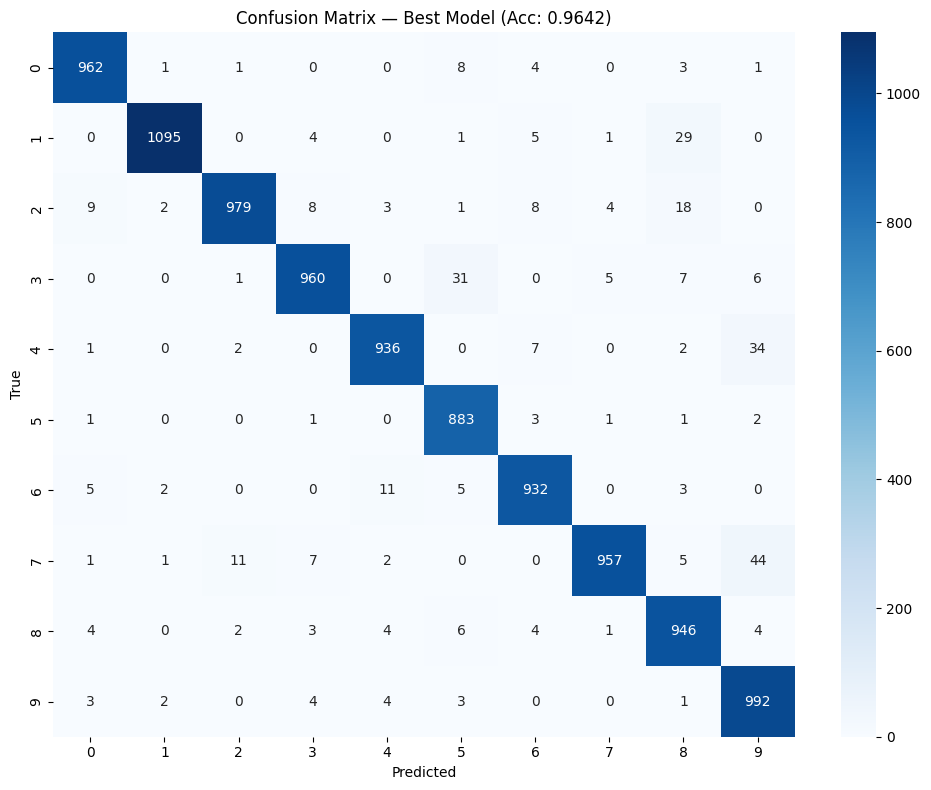

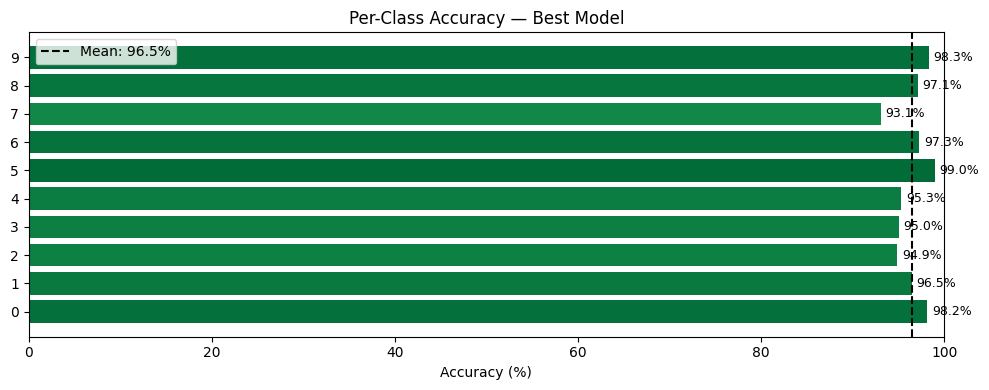

Section 2.8 done.


In [3]:
# ── Section 2.8 Error Analysis ──────────────────────────────────────────

# Load already saved best model instead of retraining
import sys
sys.path.insert(0, '../src')
from ann.neural_network import NeuralNetwork

best_args = make_args(
    dataset      = 'mnist',
    num_layers   = 3,
    hidden_size  = 128,
    activation   = 'relu',
    optimizer    = 'rmsprop',
    learning_rate= 0.001,
    epochs       = 20,
    weight_init  = 'xavier',
    weight_decay = 0.0005,
)

# Load saved weights
best_model = NeuralNetwork(best_args)
saved_weights = np.load('../src/best_model.npy', allow_pickle=True).item()
best_model.set_weights(saved_weights)
print("Loaded best model weights.")

# Predictions on test set
logits = best_model.forward(X_test)
preds  = np.argmax(logits, axis=1)
test_acc = float(np.mean(preds == y_test.astype(int)))
print(f"Test Accuracy: {test_acc:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test.astype(int), preds)

run = wandb.init(
    project = WANDB_PROJECT,
    entity  = WANDB_ENTITY,
    name    = 'confusion_matrix',
    reinit  = 'finish_previous',
    config  = {'dataset': 'mnist', 'test_acc': test_acc}
)

# Plot 1: Confusion Matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Best Model (Acc: {test_acc:.4f})')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
wandb.log({'confusion_matrix': wandb.Image('confusion_matrix.png')})
plt.show()

# Plot 2: Per-class accuracy bar chart (creative visualization)
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig2, ax2 = plt.subplots(figsize=(10, 4))
colors = plt.cm.RdYlGn(per_class_acc)
bars   = ax2.barh(class_names, per_class_acc * 100, color=colors)
ax2.set_xlabel('Accuracy (%)')
ax2.set_xlim(0, 100)
ax2.set_title('Per-Class Accuracy — Best Model')
ax2.axvline(x=np.mean(per_class_acc) * 100,
            color='black', linestyle='--', label=f'Mean: {np.mean(per_class_acc)*100:.1f}%')
# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, per_class_acc)):
    ax2.text(acc * 100 + 0.5, bar.get_y() + bar.get_height()/2,
             f'{acc*100:.1f}%', va='center', fontsize=9)
ax2.legend()
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150)
wandb.log({'per_class_accuracy': wandb.Image('per_class_accuracy.png')})
plt.show()

# Log per-class accuracy as a table too
table = wandb.Table(columns=['digit', 'accuracy'])
for i, acc in enumerate(per_class_acc):
    table.add_data(class_names[i], round(float(acc), 4))
wandb.log({'per_class_accuracy_table': table})

run.finish()
print('Section 2.8 done.')

## 2.9 Weight Initialization & Symmetry Breaking

In [3]:
def track_neuron_gradients(weight_init, run_name, n_neurons=5, n_iterations=50):
    """Track gradients of 5 neurons in first hidden layer for 50 iterations."""
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = run_name,
        reinit  = 'finish_previous',
        config  = {'weight_init': weight_init, 'dataset': 'mnist'}
    )
    args  = make_args(
        dataset      = 'mnist',
        weight_init  = weight_init,
        num_layers   = 3,
        hidden_size  = 64,
        activation   = 'relu',
        optimizer    = 'sgd',
        learning_rate= 0.01,
        epochs       = 1,
    )
    model = NeuralNetwork(args)

    for step in range(n_iterations):
        idx    = np.random.choice(len(X_train), size=32, replace=False)
        Xb, yb = X_train[idx], y_train[idx]

        logits = model.forward(Xb)
        model.backward(yb, logits)
        model.update_weights()

        # grad_W[-1] = first hidden layer (reversed order)
        first_layer_grad = model.grad_W[-1]   # shape (784, 64)

        log_dict = {'step': step}
        for j in range(n_neurons):
            # Track gradient norm of each individual neuron's weights
            grad_norm = float(np.linalg.norm(first_layer_grad[:, j]))
            log_dict[f'neuron_{j}_grad_norm'] = grad_norm

        wandb.log(log_dict)

    run.finish()

track_neuron_gradients('zeros',  run_name='init_zeros')
track_neuron_gradients('xavier', run_name='init_xavier')
print('Section 2.9 done.')

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\agraw\_netrc.
wandb: Currently logged in as: agrawalritik2001 (agrawalritik2001-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


neuron_0_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_1_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_2_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_3_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
neuron_4_grad_norm,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,0
neuron_1_grad_norm,0
neuron_2_grad_norm,0
neuron_3_grad_norm,0
neuron_4_grad_norm,0


neuron_0_grad_norm,▂▃▁▂█▃▂▂▃▄▆▂▁▂▄▅▂▃▂▂▄▂▅▄▃▄▅▃▁▇▃▅▃▃▅▆▅▁▁▆
neuron_1_grad_norm,▃▃▄▁▂▄▃▃▄▃▁█▆▂▂▄▆▃▃█▄▄▄▄▂▂▂▆▆▃▅▂▂▂▂▄▄▁▁▂
neuron_2_grad_norm,▄▆▃▄▄▃█▆▅▄▇▂▃▂▂▂▁▂▃▄▃▃▄▃▄▁▃▃▃▅▇▄▃▄▁▃▃▃▃▇
neuron_3_grad_norm,▅▄▇▄▃▁█▄▃▁▅▃▃▄▁▅▄▄▄▅▅▄▃▂▃▄▃▃▆▂▄▇▄▅▆▄▅▃▃▄
neuron_4_grad_norm,▃▃▃▅▃▅▆▄▃▃▅█▄▃▅▂▂▄▃▆▂▂▃▇▃▃▂▅▁▃▂▂█▃▂▃▃▃▆▄
step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
neuron_0_grad_norm,0.1767
neuron_1_grad_norm,0.02888
neuron_2_grad_norm,0.15066
neuron_3_grad_norm,0.03033
neuron_4_grad_norm,0.05139


Section 2.9 done.


## 2.10 Fashion-MNIST Transfer Challenge

In [4]:
wandb.finish()

# 3 configurations inspired by best MNIST results
configs = [
    dict(num_layers=3, hidden_size=128, activation='relu',  optimizer='rmsprop', lr=0.001, name='config1_rmsprop_relu'),
    dict(num_layers=4, hidden_size=128, activation='relu',  optimizer='momentum', lr=0.01,  name='config2_momentum_relu'),
    dict(num_layers=3, hidden_size=128, activation='tanh',  optimizer='rmsprop', lr=0.001, name='config3_rmsprop_tanh'),
]

# Load Fashion-MNIST fresh
(Xf_train, yf_train), (Xf_val, yf_val), (Xf_test, yf_test), fashion_classes = \
    load_data('fashion_mnist', val_split=0.1)

results = []
for cfg in configs:
    run = wandb.init(
        project = WANDB_PROJECT,
        entity  = WANDB_ENTITY,
        name    = f'transfer_{cfg["name"]}',
        reinit  = 'finish_previous',                    # ← add
        config  = {k: v for k, v in cfg.items() if k != 'name'}
    )

    args  = make_args(
        dataset       = 'fashion_mnist',
        num_layers    = cfg['num_layers'],
        hidden_size   = cfg['hidden_size'],
        activation    = cfg['activation'],
        optimizer     = cfg['optimizer'],
        learning_rate = cfg['lr'],
        epochs        = 15,
    )
    model = NeuralNetwork(args)
    model.train(
        Xf_train, yf_train,
        X_val      = Xf_val,
        y_val      = yf_val,
        epochs     = 15,
        batch_size = 32,
        wandb_log  = True,
    )

    test_acc, test_loss = model.evaluate(Xf_test, yf_test)
    wandb.log({'test_acc': test_acc, 'test_loss': test_loss})
    results.append({'name': cfg['name'], 'test_acc': test_acc})
    print(f"{cfg['name']:35s} → Test Acc: {test_acc:.4f}")
    run.finish()

best = max(results, key=lambda x: x['test_acc'])
print(f'\nResults summary:')
for r in results:
    print(f"  {r['name']:35s}: {r['test_acc']:.4f}")
print(f'\nBest config: {best["name"]} → {best["test_acc"]:.4f}')
print('Section 2.10 done.')

Dataset: fashion_mnist
  Train : 54000 samples
  Val   : 6000   samples
  Test  : 10000   samples
  Input : 784 features


Epoch   1/15 | Train Loss: 0.5191 | Train Acc: 0.8553 | Val Loss: 0.3891 | Val Acc: 0.8577
Epoch   2/15 | Train Loss: 0.3990 | Train Acc: 0.8403 | Val Loss: 0.4345 | Val Acc: 0.8343
Epoch   3/15 | Train Loss: 0.3772 | Train Acc: 0.8652 | Val Loss: 0.4169 | Val Acc: 0.8605
Epoch   4/15 | Train Loss: 0.3709 | Train Acc: 0.8827 | Val Loss: 0.3699 | Val Acc: 0.8772
Epoch   5/15 | Train Loss: 0.3668 | Train Acc: 0.8598 | Val Loss: 0.4486 | Val Acc: 0.8565
Epoch   6/15 | Train Loss: 0.3656 | Train Acc: 0.8828 | Val Loss: 0.3903 | Val Acc: 0.8703
Epoch   7/15 | Train Loss: 0.3617 | Train Acc: 0.8857 | Val Loss: 0.3976 | Val Acc: 0.8775
Epoch   8/15 | Train Loss: 0.3633 | Train Acc: 0.8932 | Val Loss: 0.4055 | Val Acc: 0.8828
Epoch   9/15 | Train Loss: 0.3580 | Train Acc: 0.8923 | Val Loss: 0.4001 | Val Acc: 0.8813
Epoch  10/15 | Train Loss: 0.3599 | Train Acc: 0.8818 | Val Loss: 0.4293 | Val Acc: 0.8730
Epoch  11/15 | Train Loss: 0.3586 | Train Acc: 0.8839 | Val Loss: 0.4053 | Val Acc: 0.8813

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_loss,▁
train_acc,▃▁▄▆▃▆▇▇▇▆▆██▆█
train_loss,█▃▂▂▂▂▂▂▂▂▂▁▁▁▁
val_acc,▄▁▄▆▄▆▆▇▇▆▇█▇▆▇
val_loss,▂▄▃▁▅▂▂▃▃▄▃▂▃█▆
epoch,15
test_acc,0.8659
test_loss,0.55113
train_acc,0.89494


Epoch   1/15 | Train Loss: 0.5627 | Train Acc: 0.8186 | Val Loss: 0.4972 | Val Acc: 0.8198
Epoch   2/15 | Train Loss: 0.3997 | Train Acc: 0.8588 | Val Loss: 0.3812 | Val Acc: 0.8585
Epoch   3/15 | Train Loss: 0.3561 | Train Acc: 0.8699 | Val Loss: 0.3741 | Val Acc: 0.8653
Epoch   4/15 | Train Loss: 0.3333 | Train Acc: 0.8881 | Val Loss: 0.3254 | Val Acc: 0.8785
Epoch   5/15 | Train Loss: 0.3151 | Train Acc: 0.8958 | Val Loss: 0.3157 | Val Acc: 0.8847
Epoch   6/15 | Train Loss: 0.2991 | Train Acc: 0.8916 | Val Loss: 0.3291 | Val Acc: 0.8790
Epoch   7/15 | Train Loss: 0.2865 | Train Acc: 0.9001 | Val Loss: 0.3033 | Val Acc: 0.8887
Epoch   8/15 | Train Loss: 0.2792 | Train Acc: 0.9068 | Val Loss: 0.3031 | Val Acc: 0.8917
Epoch   9/15 | Train Loss: 0.2662 | Train Acc: 0.9040 | Val Loss: 0.3014 | Val Acc: 0.8883
Epoch  10/15 | Train Loss: 0.2574 | Train Acc: 0.9122 | Val Loss: 0.3043 | Val Acc: 0.8903
Epoch  11/15 | Train Loss: 0.2479 | Train Acc: 0.9071 | Val Loss: 0.3101 | Val Acc: 0.8878

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_loss,▁
train_acc,▁▄▅▆▆▆▇▇▇█▇█▇██
train_loss,█▅▄▃▃▃▂▂▂▂▁▁▁▁▁
val_acc,▁▅▅▆▇▆▇█▇█▇█▇█▇
val_loss,█▄▄▂▂▂▁▁▁▁▁▁▂▁▁
epoch,15
test_acc,0.8798
test_loss,0.33494
train_acc,0.9178


Epoch   1/15 | Train Loss: 0.5038 | Train Acc: 0.8371 | Val Loss: 0.4220 | Val Acc: 0.8417
Epoch   2/15 | Train Loss: 0.3829 | Train Acc: 0.8692 | Val Loss: 0.3586 | Val Acc: 0.8720
Epoch   3/15 | Train Loss: 0.3449 | Train Acc: 0.8832 | Val Loss: 0.3354 | Val Acc: 0.8778
Epoch   4/15 | Train Loss: 0.3197 | Train Acc: 0.8957 | Val Loss: 0.3136 | Val Acc: 0.8822
Epoch   5/15 | Train Loss: 0.3020 | Train Acc: 0.8923 | Val Loss: 0.3172 | Val Acc: 0.8833
Epoch   6/15 | Train Loss: 0.2891 | Train Acc: 0.8999 | Val Loss: 0.3159 | Val Acc: 0.8848
Epoch   7/15 | Train Loss: 0.2760 | Train Acc: 0.8924 | Val Loss: 0.3360 | Val Acc: 0.8817
Epoch   8/15 | Train Loss: 0.2649 | Train Acc: 0.9085 | Val Loss: 0.3061 | Val Acc: 0.8893
Epoch   9/15 | Train Loss: 0.2555 | Train Acc: 0.9009 | Val Loss: 0.3269 | Val Acc: 0.8837
Epoch  10/15 | Train Loss: 0.2471 | Train Acc: 0.8951 | Val Loss: 0.3464 | Val Acc: 0.8757
Epoch  11/15 | Train Loss: 0.2407 | Train Acc: 0.9237 | Val Loss: 0.2963 | Val Acc: 0.8972

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
test_acc,▁
test_loss,▁
train_acc,▁▄▅▆▅▆▅▇▆▆██▇▇█
train_loss,█▅▄▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▅▆▆▆▆▆▇▆▅██▇▇▆
val_loss,█▄▃▂▂▂▃▂▃▄▁▂▃▂▃
epoch,15
test_acc,0.875
test_loss,0.37267
train_acc,0.91857



Results summary:
  config1_rmsprop_relu               : 0.8659
  config2_momentum_relu              : 0.8798
  config3_rmsprop_tanh               : 0.8750

Best config: config2_momentum_relu → 0.8798
Section 2.10 done.
